In [66]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [67]:
sns.set_style('ticks')
sns.set_style('whitegrid')

In [68]:
df = pd.read_csv("custdata.tsv", sep="\t")
df

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
0,2068,F,NaN,11300,Married,True,Homeowner free and clear,False,2.0,49.0,Michigan
1,2073,F,NaN,0,Married,True,Rented,True,3.0,40.0,Florida
2,2848,M,True,4500,Never Married,False,Rented,True,3.0,22.0,Georgia
3,5641,M,True,20000,Never Married,False,Occupied with no rent,False,0.0,22.0,New Mexico
4,6369,F,True,12000,Never Married,True,Rented,True,1.0,31.0,Florida
...,...,...,...,...,...,...,...,...,...,...,...
995,1411132,F,False,46000,Divorced/Separated,True,Rented,True,1.0,56.0,Florida
996,1411860,F,NaN,5400,Widowed,True,NaN,NaN,NaN,89.0,Pennsylvania
997,1412161,M,True,38500,Married,True,Rented,True,1.0,29.0,Georgia
998,1412971,M,NaN,43400,Married,True,Homeowner free and clear,False,1.0,88.0,Ohio


data analysis - Imported Dataset (custdata.tsv)
----------------------------------
The dataset does not look to be clean structured raw data. There are missing values denoted as NA. Need to remmove these data pooints. The raw data needs to be cleaned.

In [69]:
df1 = df[df["is.employed"].notna()]
df2 = df1[df1["recent.move"].notna()]
df2

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
2,2848,M,True,4500,Never Married,False,Rented,True,3.0,22.0,Georgia
3,5641,M,True,20000,Never Married,False,Occupied with no rent,False,0.0,22.0,New Mexico
4,6369,F,True,12000,Never Married,True,Rented,True,1.0,31.0,Florida
5,8322,F,True,180000,Never Married,True,Homeowner with mortgage/loan,False,1.0,40.0,New York
6,8521,M,True,120000,Never Married,True,Homeowner free and clear,True,1.0,39.0,Idaho
...,...,...,...,...,...,...,...,...,...,...,...
991,1407916,M,True,30000,Never Married,True,Homeowner with mortgage/loan,False,1.0,46.0,Louisiana
992,1408280,F,True,18000,Married,True,Homeowner with mortgage/loan,False,4.0,52.0,Wisconsin
995,1411132,F,False,46000,Divorced/Separated,True,Rented,True,1.0,56.0,Florida
997,1412161,M,True,38500,Married,True,Rented,True,1.0,29.0,Georgia


data analysis - Raw Data (custdata.tsv)
----------------------------------
Using the notna() function we were able to filter the columns (df series) for values that were not a number.

create a Housing type bar chart

sort values in columns and prepare data to plot bar graph.

In [70]:
df2.groupby("housing.type")["income"].mean().sort_values()

housing.type
Occupied with no rent           31362.500000
Rented                          44933.165441
Homeowner with mortgage/loan    82806.080495
Homeowner free and clear        84374.442623
Name: income, dtype: float64

In [71]:
df2_sorted_mean = (
    df2.groupby("housing.type")["income"]
       .mean()
       .sort_values()
)

ordered_categories = df2_sorted_mean.index.tolist()

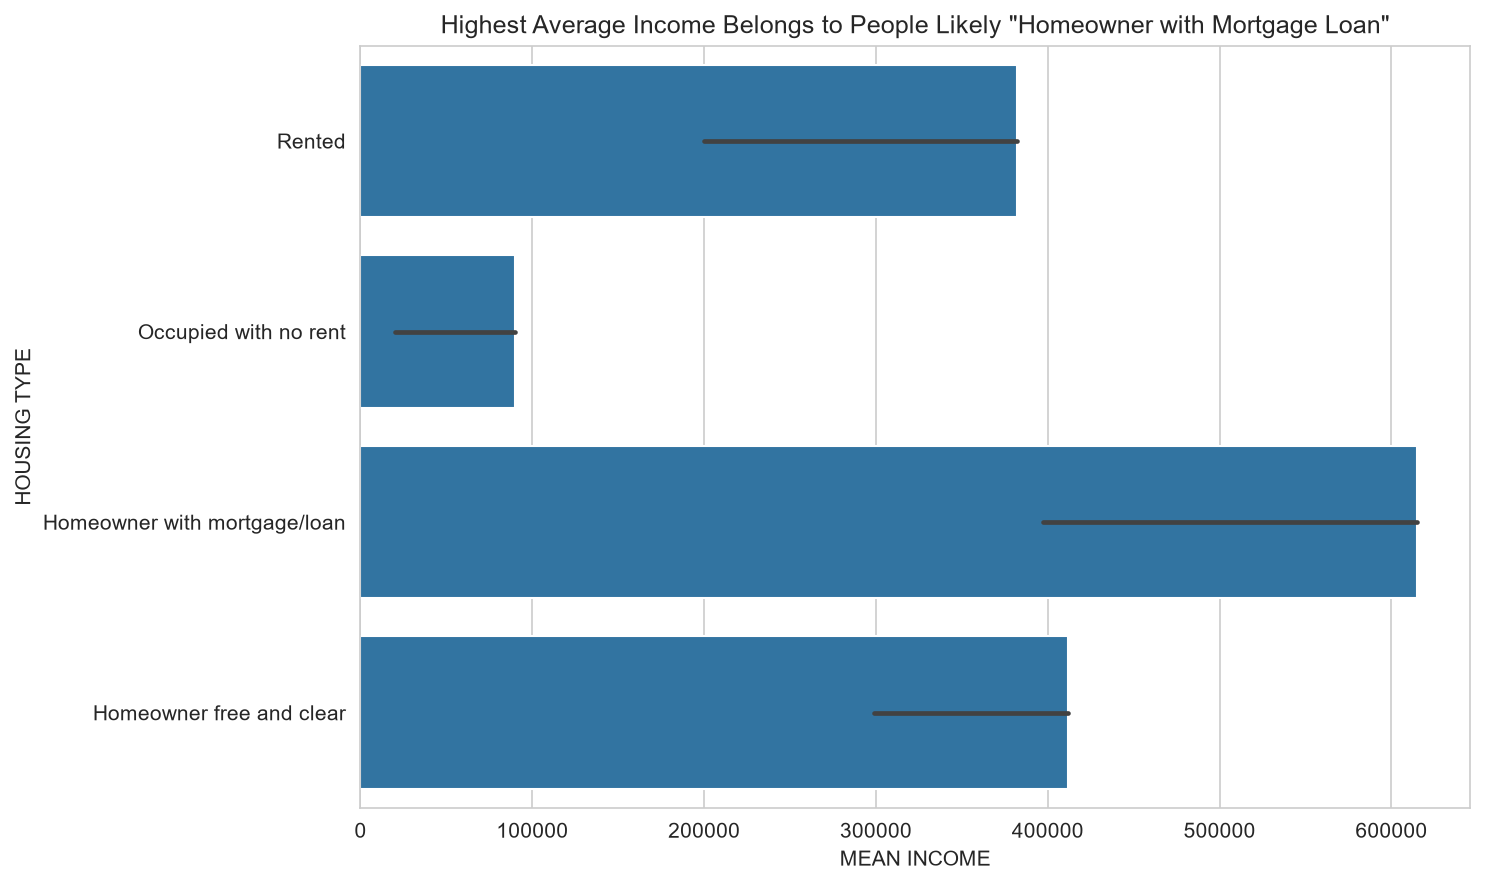

In [72]:
plt.figure(figsize=(10, 6), dpi=150)

sns.barplot(
    x='income',
    y='housing.type',
    data=df2,
    estimator='max'
)

plt.title('Highest Average Income Belongs to People Likely "Homeowner with Mortgage Loan"')
plt.xlabel("MEAN INCOME")
plt.ylabel("HOUSING TYPE")

plt.tight_layout()
plt.savefig('custHsngType_BarGrph.png')
plt.show()

data analysis - Bar Plot of Average Income per Housing Type
----------------------------------
We see in the "Homeowner with Mortgage Loan" housing type has the highest average income. This is somewhat suprising as "Homeowner Free and Clear" shows the highest average income in the calculations on the data. Since the length of the datasets used to create the graph, I had to omit 564 lines to make the datasets equal. This may have skewed the data.

URL for This Assignmemnt's Repo
================================================================================

https://github.com/chillyvee70/cs82a-portfolio/tree/main/module5